# Compare Sonnet vs Toto

This notebook performs a brief 10-epoch training run for Sonnet and conducts zero-shot inference with Toto using a rolling-window evaluation. It reports Correlation, MAE, MSE, RMSE, and a modified SMAPE at the target forecasting horizon.

In [ ]:
# First, install required packages
!pip install PrettyTable toto-ts

In [ ]:
from types import SimpleNamespace
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning as L
from prettytable import PrettyTable

from toto.data.util.dataset import MaskedTimeseries
from toto.inference.forecaster import TotoForecaster
from toto.model.toto import Toto

from sonnet.data.weatherDataloader import CustomWeatherDataModule, get_weather_paths
from sonnet.model_config import ModelConfig

In [2]:
# Parameters 
city_year = 'london_2018'   # format: city_endYear
model_key = 'sonnet'        
batch_size = 64
seq_length = 28
pred_length = 4
epochs = 10
lr = 1e-3
weight_decay = 1e-8
out_prefix = 'london'
toto_limit = None
toto_num_samples = 256  # Number of samples for probabilistic forecasting
toto_context_length = 4096  # Maximum context length for Toto

In [3]:
def build_datamodule(city_year: str, batch_size: int, seq_length: int, pred_length: int):
    params = dict(
        seq_length=seq_length,
        pred_length=pred_length,
        scale=True,
        task='MB',
        target_column='t850',
        start_year=1980,
    )
    dm = CustomWeatherDataModule(city_year, batch_size=batch_size, **params)
    dm.setup()
    return dm

In [4]:
def build_model(model_name: str, dm, seq_length: int, pred_length: int, lr: float, weight_decay: float):
    from hydra import initialize_config_dir, compose
    from omegaconf import OmegaConf

    cfg_dir = os.path.join(os.path.dirname(os.getcwd()), 'configs')
    with initialize_config_dir(config_dir=cfg_dir, version_base=None):
        cfg = compose(config_name='config', overrides=[f'model={model_name}'])
    yaml_model_params = OmegaConf.to_container(cfg.model.model_params, resolve=True) if hasattr(cfg.model, 'model_params') else {}

    model_cfg = {
        **yaml_model_params,
        'seq_len': seq_length,
        'pred_len': pred_length,
        'enc_in': dm.num_variables,
        'dec_in': dm.num_variables,
        'seasonality': None,
        'data_group': 'weatherbench',
        'c_out': 1,
    }

    configs = SimpleNamespace(**model_cfg)
    model_reg = ModelConfig(name=model_name)
    ModelClass = model_reg.model_class

    exp_params = {
        'lr': lr,
        'weight_decay': weight_decay,
        'lr_scheduler': 'cosine_lr',
        'reverse_eval': False,
    }

    model = ModelClass(configs, datamodule=dm, **exp_params)
    return model

In [5]:
def inference_collect_last(model, dm, device):
    model = model.to(device)
    model.eval()

    loader = dm.test_dataloader()
    preds = []
    trues = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            out = out.cpu().numpy()
            y = y.cpu().numpy()

            if out.ndim == 3:
                preds.extend(out[:, -1, -1].tolist())
                trues.extend(y[:, -1, -1].tolist())
            else:
                preds.extend(out[:, -1].tolist())
                trues.extend(y[:, -1].tolist())

    preds = np.array(preds)
    trues = np.array(trues)

    if dm.scaler is not None:
        try:
            preds = dm.scaler.inverse_transform(preds.reshape(-1, 1)).reshape(-1)
            trues = dm.scaler.inverse_transform(trues.reshape(-1, 1)).reshape(-1)
        except Exception:
            print('Inverse transform failed; keeping scaled values')

    timestamps = dm.dates_iso[: len(preds)]
    df = pd.DataFrame({'timestamp': pd.to_datetime(timestamps), 'pred_last': preds, 'true_last': trues})
    return df

In [12]:
def run_toto_forecasting(
    raw_csv_path: str, 
    target_column: str, 
    target_timestamps, 
    prediction_length: int, 
    out_prefix: str, 
    forecaster=None, 
    limit=None, 
    hours_per_step: int = 6,
    num_samples: int = 256,
    context_length: int = 4096
):
    """Run Toto forecasting with rolling window evaluation.
    
    Args:
        raw_csv_path: Path to the raw CSV data
        target_column: Column name to forecast
        target_timestamps: List of target timestamps for evaluation
        prediction_length: Number of steps to forecast
        out_prefix: Prefix for output files
        forecaster: TotoForecaster instance (will be created if None)
        limit: Maximum number of predictions to make
        hours_per_step: Hours between each timestep
        num_samples: Number of samples for probabilistic forecasting
        context_length: Maximum context length for Toto model
    """
    if forecaster is None:
        # Load the pre-trained model
        toto = Toto.from_pretrained('Datadog/Toto-Open-Base-1.0')
        toto.to('cuda')  # Move to GPU
        # Optionally compile the model for faster inference
        toto.compile()
        forecaster = TotoForecaster(toto.model)

    raw = pd.read_csv(raw_csv_path, index_col=0)
    raw.index = pd.to_datetime(raw.index)

    results = []
    total = len(target_timestamps)
    if limit is not None:
        total = min(total, int(limit))

    for i, ts in enumerate(target_timestamps[:total]):
        target_ts = pd.to_datetime(ts)
        origin_time = target_ts - pd.Timedelta(hours=hours_per_step * prediction_length)

        # Get historical data up to origin_time
        history = raw.loc[:origin_time].copy()
        
        # Limit context to last context_length timesteps
        if len(history) > context_length:
            history = history.iloc[-context_length:]
        
        # Extract the target series and convert to tensor (time_steps,)
        target_series = torch.tensor(history[target_column].values, dtype=torch.float32)
        
        # Toto expects (channels, time_steps), so we add a channel dimension
        input_series = target_series.unsqueeze(0).to('cuda')  # (1, time_steps)
        
        # Prepare timestamp information (optional, but expected by API)
        time_steps = input_series.shape[1]
        timestamp_seconds = torch.zeros(1, time_steps).to('cuda')
        time_interval_seconds = torch.full((1,), hours_per_step * 3600).to('cuda')  # Convert hours to seconds
        
        # Create a MaskedTimeseries object
        inputs = MaskedTimeseries(
            series=input_series,
            padding_mask=torch.full_like(input_series, True, dtype=torch.bool),
            id_mask=torch.zeros_like(input_series),
            timestamp_seconds=timestamp_seconds,
            time_interval_seconds=time_interval_seconds,
        )
        
        # Generate forecasts
        forecast = forecaster.forecast(
            inputs,
            prediction_length=prediction_length,
            num_samples=num_samples,
            samples_per_batch=num_samples,
        )
        
        # Get median prediction at the target horizon
        median_prediction = forecast.median  # Shape: (1, prediction_length)
        pred_val = median_prediction[0, 0, -1].cpu().item()  # Last timestep
        
        true_val = raw.loc[target_ts, target_column]
        results.append({'timestamp': target_ts, 'pred_last': pred_val, 'true_last': true_val})

        if (i + 1) % 10 == 0 or (i + 1) == total:
            print(f'Toto rolling: processed {i+1}/{total} origins')

    df_res = pd.DataFrame(results)
    return df_res, forecaster

## Train Sonnet

In [7]:
dm = build_datamodule(city_year, batch_size, seq_length, pred_length)

model = build_model(model_key, dm, seq_length, pred_length, lr, weight_decay)

devices = 1
trainer = L.Trainer(max_epochs=epochs, accelerator='auto', devices=devices, enable_checkpointing=False, logger=False)
print(f'Starting training for {epochs} epochs...')
trainer.fit(model, dm.train_dataloader(), dm.val_dataloader())

print('Running inference on test set (Sonnet)...')
df_sonnet = inference_collect_last(model, dm, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

Experiment with target column: t850
Experiment with target column: t850
Experiment with target column: t850


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Starting training for 10 epochs...


You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name         | Type       | Params
--------------------------------------------
0 | target_embed | Linear     | 64    
1 | exog_embed   | Linear     | 1.4 K 
2 | blocks       | ModuleList | 32.4 K
3 | decoder      | Sequential | 2.7 K 
4 | project      | Linear     | 5     
--------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Running inference on test set (Sonnet)...


In [8]:
sonnet_corr = np.corrcoef(df_sonnet['pred_last'], df_sonnet['true_last'])[0, 1]
sonnet_mae = np.mean(np.abs(df_sonnet['pred_last'] - df_sonnet['true_last']))
sonnet_mse = np.mean((df_sonnet['pred_last'] - df_sonnet['true_last']) ** 2)
sonnet_rmse = np.sqrt(np.mean((df_sonnet['pred_last'] - df_sonnet['true_last']) ** 2))
a = np.min(df_sonnet['true_last']) + 30
sonnet_smape = 100.0 * np.mean(2.0 * np.abs(df_sonnet['pred_last'] - df_sonnet['true_last']) / (np.abs(df_sonnet['pred_last'] - a) + np.abs(df_sonnet['true_last'] - a) + 1e-8))

# prettytable
table = PrettyTable()
table.field_names = ["Model", "Correlation", "MAE", "MSE", "RMSE", "SMAPE"]
table.add_row(["Sonnet", f"{sonnet_corr:.6f}", f"{sonnet_mae:.6f}", f"{sonnet_mse:.6f}", f"{sonnet_rmse:.6f}", f"{sonnet_smape:.6f}"])
print(table)

+--------+-------------+----------+----------+----------+-----------+
| Model  | Correlation |   MAE    |   MSE    |   RMSE   |   SMAPE   |
+--------+-------------+----------+----------+----------+-----------+
| Sonnet |   0.921888  | 1.795743 | 5.673644 | 2.381941 | 23.394578 |
+--------+-------------+----------+----------+----------+-----------+


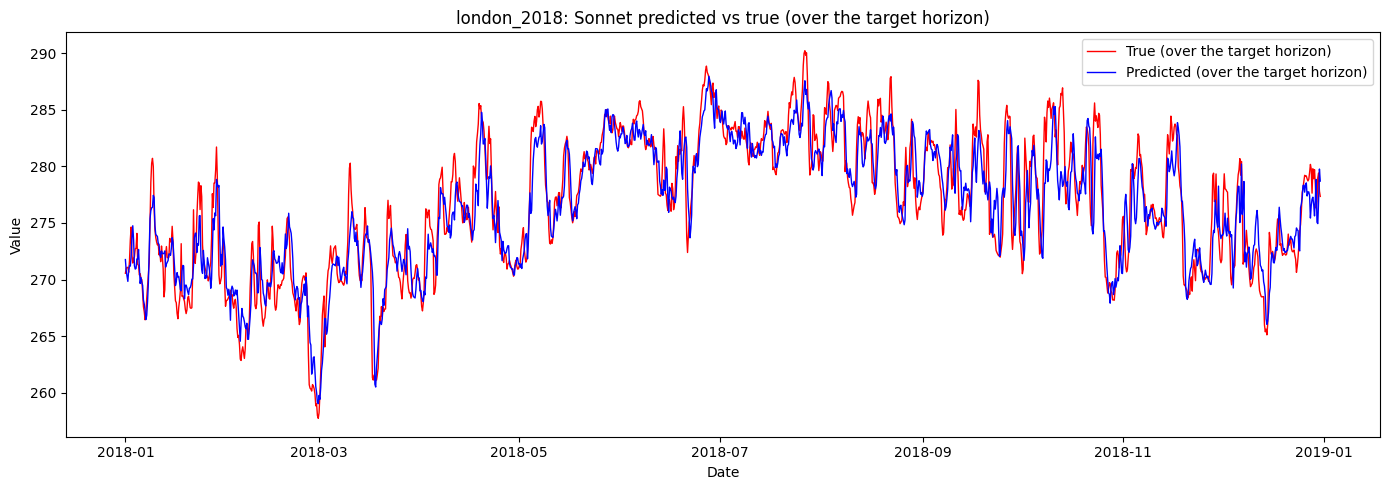

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df_sonnet['timestamp'], df_sonnet['true_last'], label='True (over the target horizon)', color='red', linewidth=1)
plt.plot(df_sonnet['timestamp'], df_sonnet['pred_last'], label='Predicted (over the target horizon)', color='blue', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f"{city_year}: Sonnet predicted vs true (over the target horizon)")
plt.legend()
plt.tight_layout()
plt.show()

## Zero-shot forecasting with Toto

In [13]:
path = get_weather_paths(city_year.split('_')[0])
df_toto, toto_forecaster = run_toto_forecasting(
    path, 
    't850', 
    dm.dates_iso, 
    pred_length, 
    out_prefix, 
    limit=toto_limit,
    num_samples=toto_num_samples,
    context_length=toto_context_length
)

Toto rolling: processed 10/1457 origins
Toto rolling: processed 20/1457 origins
Toto rolling: processed 30/1457 origins
Toto rolling: processed 40/1457 origins
Toto rolling: processed 50/1457 origins
Toto rolling: processed 60/1457 origins
Toto rolling: processed 70/1457 origins
Toto rolling: processed 80/1457 origins
Toto rolling: processed 90/1457 origins
Toto rolling: processed 100/1457 origins
Toto rolling: processed 110/1457 origins
Toto rolling: processed 120/1457 origins
Toto rolling: processed 130/1457 origins
Toto rolling: processed 140/1457 origins
Toto rolling: processed 150/1457 origins
Toto rolling: processed 160/1457 origins
Toto rolling: processed 170/1457 origins
Toto rolling: processed 180/1457 origins
Toto rolling: processed 190/1457 origins
Toto rolling: processed 200/1457 origins
Toto rolling: processed 210/1457 origins
Toto rolling: processed 220/1457 origins
Toto rolling: processed 230/1457 origins
Toto rolling: processed 240/1457 origins
Toto rolling: processed 2

In [14]:
toto_corr = np.corrcoef(df_toto['pred_last'], df_toto['true_last'])[0, 1]
toto_mae = np.mean(np.abs(df_toto['pred_last'] - df_toto['true_last']))
toto_mse = np.mean((df_toto['pred_last'] - df_toto['true_last']) ** 2)
toto_rmse = np.sqrt(np.mean((df_toto['pred_last'] - df_toto['true_last']) ** 2))
toto_smape = 100.0 * np.mean(2.0 * np.abs(df_toto['pred_last'] - df_toto['true_last']) / (np.abs(df_toto['pred_last'] - a) + np.abs(df_toto['true_last'] - a) + 1e-8))

# prettytable
table = PrettyTable()
table.field_names = ["Model", "Correlation", "MAE", "MSE", "RMSE", "SMAPE"]
table.add_row(["Toto", f"{toto_corr:.6f}", f"{toto_mae:.6f}", f"{toto_mse:.6f}", f"{toto_rmse:.6f}", f"{toto_smape:.6f}"])
print(table)

+-------+-------------+----------+-----------+----------+-----------+
| Model | Correlation |   MAE    |    MSE    |   RMSE   |   SMAPE   |
+-------+-------------+----------+-----------+----------+-----------+
|  Toto |   0.846857  | 2.498587 | 10.615331 | 3.258118 | 30.098325 |
+-------+-------------+----------+-----------+----------+-----------+


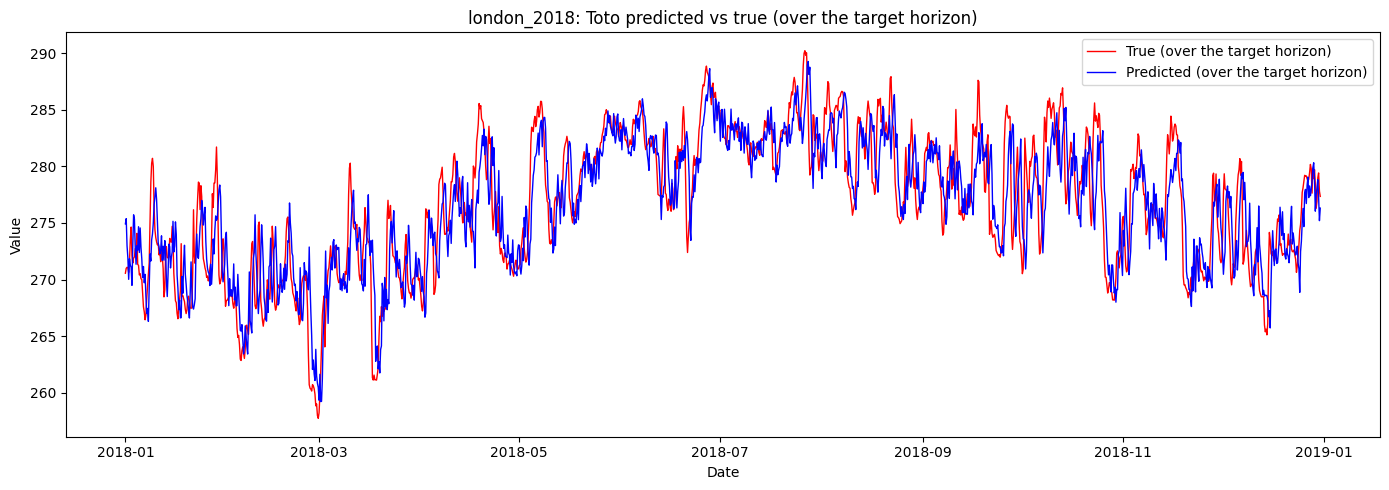

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df_toto['timestamp'], df_toto['true_last'], label='True (over the target horizon)', color='red', linewidth=1)
plt.plot(df_toto['timestamp'], df_toto['pred_last'], label='Predicted (over the target horizon)', color='blue', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f"{city_year}: Toto predicted vs true (over the target horizon)")
plt.legend()
plt.tight_layout()
plt.show()